# Udemy Courses Dataset: Preprocessing

## 1. Notebook Goal

This notebook prepares a clean recommendation-ready version of the Udemy Courses dataset. The processed dataset will be used later by the TF-IDF and KNN recommenders, so the goal is to keep the transformation simple, transparent, and reproducible.


## 2. Import Libraries

The preprocessing step mainly uses `pandas` for data cleaning. `matplotlib` and `seaborn` are used only for a small visual summary of the preprocessing impact.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 3. Load Raw Dataset

The raw dataset is loaded from `data/raw/udemy_courses.csv`. A fallback path is included so the notebook can still run if it is opened from inside the `notebooks` folder.


In [2]:
raw_data_path = Path("data/raw/udemy_courses.csv")
if not raw_data_path.exists():
    raw_data_path = Path("../data/raw/udemy_courses.csv")

df_raw = pd.read_csv(raw_data_path)
df_raw.head()


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,2017-05-30T20:07:24Z,Business Finance
4,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,2016-12-13T14:57:18Z,Business Finance


The raw dataset loads correctly and contains course metadata such as course titles, subjects, levels, prices, subscribers, reviews, and course duration. These fields are enough for a first version of a content-based recommender.


## 4. Select Recommendation Features

The recommender models do not need every column from the raw dataset. We keep the main course identifier, text/category fields, and numeric popularity or course-size indicators. Columns such as URL and publication timestamp are excluded because they are not required for the first recommender versions.


In [3]:
recommendation_columns = [
    "course_id",
    "course_title",
    "subject",
    "level",
    "num_subscribers",
    "num_reviews",
    "price",
    "content_duration",
]

df = df_raw[recommendation_columns].copy()
df.head()


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration
0,1070968,Ultimate Investment Banking Course,Business Finance,All Levels,2147,23,200,1.5
1,1113822,Complete GST Course & Certification - Grow You...,Business Finance,All Levels,2792,923,75,39.0
2,1006314,Financial Modeling for Business Analysts and C...,Business Finance,Intermediate Level,2174,74,45,2.5
3,1210588,Beginner to Pro - Financial Analysis in Excel ...,Business Finance,All Levels,2451,11,95,3.0
4,1011058,How To Maximize Your Profits Trading Options,Business Finance,Intermediate Level,1276,45,200,2.0


The selected dataset keeps the fields that are directly useful for recommendations. `course_id` is retained as a stable identifier, while `course_title`, `subject`, and `level` will become the main text input for the recommender models.


## 5. Initial Data Quality Snapshot

Before changing the data, we check missing values and duplicates. This gives us a clear before/after comparison for the preprocessing steps.


In [4]:
initial_quality = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_share": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})

print(f"Initial rows: {len(df):,}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate course IDs: {df.duplicated(subset='course_id').sum():,}")
initial_quality


Initial rows: 3,678
Exact duplicate rows: 6
Duplicate course IDs: 6


,missing_values,missing_share,dtype
course_id,0,0.0,int64
course_title,0,0.0,object
subject,0,0.0,object
level,0,0.0,object
num_subscribers,0,0.0,int64
num_reviews,0,0.0,int64
price,0,0.0,int64
content_duration,0,0.0,float64


The selected columns do not contain missing values in the current raw file. However, the dataset has 6 exact duplicate rows and 6 duplicate course IDs, so duplicate removal is needed before modeling.


## 6. Basic Text Cleaning

The text cleaning is intentionally simple and explainable: lowercase text, remove basic punctuation, and normalize repeated spaces. Advanced NLP steps such as stemming and lemmatization are not used yet.

The cleaning keeps Unicode word characters so non-English course titles are not accidentally removed.


In [5]:
def clean_text(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower()
    value = re.sub(r"[^\w+.#\s]", " ", value, flags=re.UNICODE)
    value = re.sub(r"\s+", " ", value).strip()
    return value

text_columns = ["course_title", "subject", "level"]
for column in text_columns:
    df[column] = df[column].apply(clean_text)

df[text_columns].head()


,course_title,subject,level
0,ultimate investment banking course,business finance,all levels
1,complete gst course certification grow your ca...,business finance,all levels
2,financial modeling for business analysts and c...,business finance,intermediate level
3,beginner to pro financial analysis in excel 2017,business finance,all levels
4,how to maximize your profits trading options,business finance,intermediate level


After cleaning, text fields are lowercase and more consistent. This makes later similarity calculations easier because the same words will be represented in a more standardized way.


## 7. Handle Missing Values

The current dataset does not contain missing values, but the preprocessing notebook should still define a clear policy. Rows without a course ID or title are not useful for recommendations and are removed. Missing categorical values are labeled as `unknown`, while missing numeric values are replaced with `0` so KNN can later use numeric features without errors.


In [6]:
df = df.dropna(subset=["course_id", "course_title"]).copy()

categorical_columns = ["subject", "level"]
numeric_columns = ["num_subscribers", "num_reviews", "price", "content_duration"]

for column in categorical_columns:
    df[column] = df[column].fillna("unknown")
    df[column] = df[column].replace("", "unknown")

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0)

missing_after_handling = df.isna().sum()
missing_after_handling


course_id           0
course_title        0
subject             0
level               0
num_subscribers     0
num_reviews         0
price               0
content_duration    0
dtype: int64

No missing values remain after the handling step. Keeping this check in the notebook is useful because it protects the workflow if the raw dataset changes later.


## 8. Remove Duplicate Courses

Duplicate rows and duplicate course IDs can bias recommendations because the same course may appear more than once. We first remove exact duplicate rows, then keep the first record for any repeated `course_id`.


In [7]:
rows_before_deduplication = len(df)

df = df.drop_duplicates().copy()
df = df.drop_duplicates(subset="course_id", keep="first").copy()

rows_after_deduplication = len(df)
removed_rows = rows_before_deduplication - rows_after_deduplication

print(f"Rows before deduplication: {rows_before_deduplication:,}")
print(f"Rows after deduplication: {rows_after_deduplication:,}")
print(f"Rows removed: {removed_rows:,}")


Rows before deduplication: 3,678
Rows after deduplication: 3,672
Rows removed: 6


The preprocessing step removes 6 duplicate records. The final row count is still almost the same as the original dataset, so the cleaning improves data quality without significantly reducing the available course catalog.


## 9. Create Combined Features

The `combined_features` column joins the main text fields into one model-ready text representation. This column will be the main input for the upcoming TF-IDF recommender and can also support KNN experiments when combined with numeric features.


In [8]:
df["combined_features"] = (
    df["course_title"].fillna("")
    + " "
    + df["subject"].fillna("")
    + " "
    + df["level"].fillna("")
)

df["combined_features"] = df["combined_features"].apply(clean_text)
df[["course_id", "course_title", "subject", "level", "combined_features"]].head()


,course_id,course_title,subject,level,combined_features
0,1070968,ultimate investment banking course,business finance,all levels,ultimate investment banking course business fi...
1,1113822,complete gst course certification grow your ca...,business finance,all levels,complete gst course certification grow your ca...
2,1006314,financial modeling for business analysts and c...,business finance,intermediate level,financial modeling for business analysts and c...
3,1210588,beginner to pro financial analysis in excel 2017,business finance,all levels,beginner to pro financial analysis in excel 20...
4,1011058,how to maximize your profits trading options,business finance,intermediate level,how to maximize your profits trading options b...


The combined text field now contains the course title, subject, and level in one column. This creates a simple and reusable input for both recommender notebooks, instead of repeating text preparation separately in each model.


## 10. Consistency Checks

These checks confirm that the processed dataset is ready for recommender modeling. We check for empty combined text, remaining duplicates, negative numeric values, and suspicious zero values in important numeric fields.


In [9]:
consistency_checks = pd.Series({
    "rows": len(df),
    "empty_combined_features": df["combined_features"].eq("").sum(),
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_course_ids": df.duplicated(subset="course_id").sum(),
    "negative_num_subscribers": (df["num_subscribers"] < 0).sum(),
    "negative_num_reviews": (df["num_reviews"] < 0).sum(),
    "negative_price": (df["price"] < 0).sum(),
    "negative_content_duration": (df["content_duration"] < 0).sum(),
    "zero_subscribers": (df["num_subscribers"] == 0).sum(),
    "zero_reviews": (df["num_reviews"] == 0).sum(),
    "zero_price": (df["price"] == 0).sum(),
    "zero_content_duration": (df["content_duration"] == 0).sum(),
})

consistency_checks


rows                         3672
empty_combined_features         0
duplicate_rows                  0
duplicate_course_ids            0
negative_num_subscribers        0
negative_num_reviews            0
negative_price                  0
negative_content_duration       0
zero_subscribers               65
zero_reviews                  284
zero_price                    310
zero_content_duration           1
dtype: int64

The important modeling checks look good: there are no empty `combined_features`, no remaining duplicate course IDs, and no negative numeric values. Zero values are not automatically errors: free courses can have a price of `0`, and some courses may have no subscribers or reviews yet.


## 11. Suspicious Value Summary

Zero values are not always errors, but they are important to inspect before modeling. A course can be free, new, or not yet reviewed, so these records should not be removed automatically. The chart below makes these values visible for discussion.


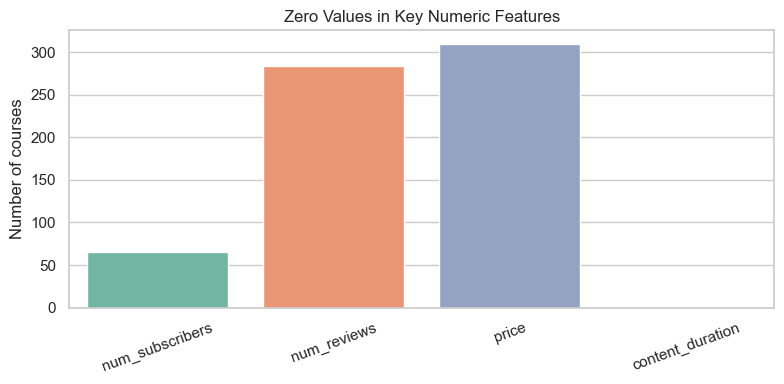

,feature,zero_count
0,num_subscribers,65
1,num_reviews,284
2,price,310
3,content_duration,1


In [10]:
zero_value_summary = pd.DataFrame({
    "feature": ["num_subscribers", "num_reviews", "price", "content_duration"],
    "zero_count": [
        (df["num_subscribers"] == 0).sum(),
        (df["num_reviews"] == 0).sum(),
        (df["price"] == 0).sum(),
        (df["content_duration"] == 0).sum(),
    ],
})

plt.figure(figsize=(8, 4))
sns.barplot(data=zero_value_summary, x="feature", y="zero_count", hue="feature", palette="Set2", legend=False)
plt.title("Zero Values in Key Numeric Features")
plt.xlabel("")
plt.ylabel("Number of courses")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

zero_value_summary


The zero-value check gives useful context for later modeling. There are 310 free courses, which is expected because Udemy includes both free and paid courses. There are also 284 courses with zero reviews and 65 courses with zero subscribers, which may represent new or less visible courses. Only 1 course has zero duration, so this is a small metadata issue rather than a major dataset problem.


## 12. Preprocessing Impact Summary

The chart below summarizes the main effect of preprocessing: duplicate rows were removed while almost the full course catalog was preserved.


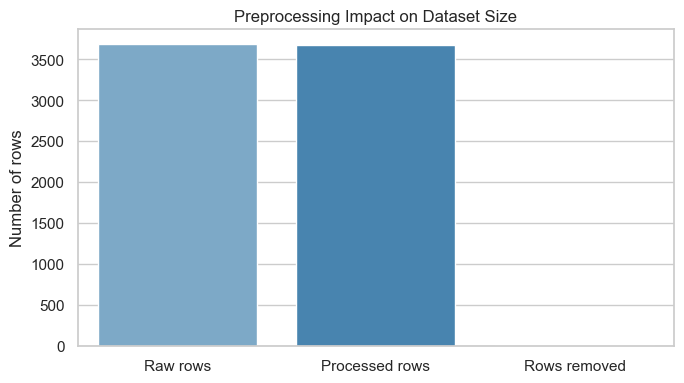

,step,count
0,Raw rows,3678
1,Processed rows,3672
2,Rows removed,6


In [11]:
summary_df = pd.DataFrame({
    "step": ["Raw rows", "Processed rows", "Rows removed"],
    "count": [len(df_raw), len(df), len(df_raw) - len(df)],
})

plt.figure(figsize=(7, 4))
sns.barplot(data=summary_df, x="step", y="count", hue="step", palette="Blues_d", legend=False)
plt.title("Preprocessing Impact on Dataset Size")
plt.xlabel("")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

summary_df


Only 6 rows are removed, which matches the duplicate check. This means the preprocessing step keeps the dataset broad enough for recommendation experiments while removing repeated course records.


## 13. Save Processed Dataset

The final processed dataset is saved in `data/processed/processed_udemy_courses.csv`. This gives both recommender notebooks a stable input file and avoids repeating preprocessing logic in multiple places.


In [12]:
processed_data_path = Path("data/processed/processed_udemy_courses.csv")
if not processed_data_path.parent.exists():
    processed_data_path = Path("../data/processed/processed_udemy_courses.csv")

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(processed_data_path, index=False)

print(f"Processed dataset saved to: {processed_data_path}")
print(f"Final shape: {df.shape}")


Processed dataset saved to: ..\data\processed\processed_udemy_courses.csv
Final shape: (3672, 9)


The processed file is now ready for the TF-IDF and KNN recommender notebooks. Saving it once here keeps the next notebooks cleaner and easier to compare.


## 14. Final Preview

The final preview confirms that the processed dataset contains the selected recommendation fields plus the new `combined_features` column.


In [13]:
df.head()


,course_id,course_title,subject,level,num_subscribers,num_reviews,price,content_duration,combined_features
0,1070968,ultimate investment banking course,business finance,all levels,2147,23,200,1.5,ultimate investment banking course business fi...
1,1113822,complete gst course certification grow your ca...,business finance,all levels,2792,923,75,39.0,complete gst course certification grow your ca...
2,1006314,financial modeling for business analysts and c...,business finance,intermediate level,2174,74,45,2.5,financial modeling for business analysts and c...
3,1210588,beginner to pro financial analysis in excel 2017,business finance,all levels,2451,11,95,3.0,beginner to pro financial analysis in excel 20...
4,1011058,how to maximize your profits trading options,business finance,intermediate level,1276,45,200,2.0,how to maximize your profits trading options b...


The final dataset has one row per course and includes the cleaned text representation needed for similarity-based recommendation. This makes `02_preprocessing.ipynb` the shared data preparation step for the next modeling notebooks.
